In [1]:
import os, random, warnings, json, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import models
from PIL import Image
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
print("✅ All imports successful")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

✅ All imports successful
PyTorch : 2.10.0
CUDA    : False


In [2]:
CFG = dict(
    data_root     = "./dataset",
    train_dir     = "train",
    val_dir       = "val",
    test_dir      = "test",
    save_dir      = "./outputs",
    img_size      = 224,
    num_classes   = 2,
    pretrained    = True,
    epochs        = 10,
    batch_size    = 32,
    num_workers   = 0,
    seed          = 42,
    lr            = 3e-4,
    weight_decay  = 1e-4,
    warmup_epochs = 5,
    label_smooth  = 0.1,
    tta_n         = 5,
    patience      = 12,
)

CLASSES = ["normal", "ulcer"]   # must match your sub-folder names exactly

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(CFG["seed"])
os.makedirs(CFG["save_dir"], exist_ok=True)
print(f"Device  : {DEVICE}")
print(f"Classes : {CLASSES}")

Device  : cpu
Classes : ['normal', 'ulcer']


In [3]:
def get_train_transforms(img_size):
    return A.Compose([
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.7, 1.0), ratio=(0.75, 1.33)),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=30, p=0.5),
        A.OneOf([
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20),
        ], p=0.6),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7)),
            A.MedianBlur(blur_limit=5),
            A.MotionBlur(blur_limit=7),
        ], p=0.3),
        A.OneOf([
            A.GaussNoise(std_range=(0.02, 0.1)),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5)),
        ], p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.CLAHE(clip_limit=4.0, p=0.3),
        A.GridDistortion(p=0.2),
        A.ElasticTransform(p=0.2),
        A.CoarseDropout(num_holes_range=(4, 8),
                        hole_height_range=(8, img_size//10),
                        hole_width_range=(8, img_size//10), p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_val_transforms(img_size):
    return A.Compose([
        A.Resize(height=int(img_size * 1.1), width=int(img_size * 1.1)),
        A.CenterCrop(height=img_size, width=img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_tta_transforms(img_size):
    base = [
        A.Resize(height=img_size, width=img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    return [
        A.Compose([*base, ToTensorV2()]),
        A.Compose([A.HorizontalFlip(p=1), *base, ToTensorV2()]),
        A.Compose([A.VerticalFlip(p=1),   *base, ToTensorV2()]),
        A.Compose([A.Rotate(limit=(90, 90), p=1), *base, ToTensorV2()]),
        A.Compose([A.RandomBrightnessContrast(0.1, 0.1, p=1), *base, ToTensorV2()]),
    ]

print("✅ Transforms defined")

✅ Transforms defined


In [4]:
class DFUDataset(Dataset):
    def __init__(self, root, class_names, transform=None):
        self.transform   = transform
        self.class_names = class_names
        self.samples     = []
        for idx, cls in enumerate(class_names):
            folder = Path(root) / cls
            if not folder.exists():
                raise FileNotFoundError(f"Folder not found: {folder}")
            for p in folder.iterdir():
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}:
                    self.samples.append((str(p), idx))
        print(f"  Loaded {len(self.samples)} images from {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

    def class_weights(self):
        counts = np.bincount([s[1] for s in self.samples], minlength=len(self.class_names))
        total  = counts.sum()
        return torch.tensor(total / (len(self.class_names) * counts), dtype=torch.float32)


train_tf = get_train_transforms(CFG["img_size"])
val_tf   = get_val_transforms(CFG["img_size"])
tta_tfs  = get_tta_transforms(CFG["img_size"])

train_ds  = DFUDataset(os.path.join(CFG["data_root"], CFG["train_dir"]), CLASSES, train_tf)
val_ds    = DFUDataset(os.path.join(CFG["data_root"], CFG["val_dir"]),   CLASSES, val_tf)
test_root = os.path.join(CFG["data_root"], CFG["test_dir"])

# ✅ num_workers=0 fixes the multiprocessing crash on macOS / Jupyter
train_ld = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                      num_workers=0, pin_memory=False, drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                      num_workers=0, pin_memory=False)

cls_wts = train_ds.class_weights().to(DEVICE)
print(f"\nClass weights : {dict(zip(CLASSES, cls_wts.cpu().numpy().round(3)))}")
print(f"Train batches : {len(train_ld)}")
print(f"Val   batches : {len(val_ld)}")

  Loaded 1016 images from ./dataset/train
  Loaded 199 images from ./dataset/val

Class weights : {'normal': np.float32(0.969), 'ulcer': np.float32(1.033)}
Train batches : 31
Val   batches : 7


In [5]:
class DFUModel(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        weights  = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.efficientnet_v2_s(weights=weights)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)


model = DFUModel(CFG["num_classes"], CFG["pretrained"]).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model on {DEVICE}")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")

✅ Model on cpu
   Total params    : 20,834,386
   Trainable params: 20,834,386


In [6]:
class SmoothedCELoss(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_cls = logits.size(1)
        log_p = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            smooth_t = torch.full_like(log_p, self.smoothing / (n_cls - 1))
            smooth_t.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(smooth_t * log_p).sum(dim=1)
        if self.weight is not None:
            loss = loss * self.weight.to(logits.device)[targets]
        return loss.mean()


def build_scheduler(optimiser, cfg, steps_per_epoch):
    warmup_steps = cfg["warmup_epochs"] * steps_per_epoch
    total_steps  = cfg["epochs"]        * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)


criterion = SmoothedCELoss(CFG["label_smooth"], weight=cls_wts)
optimiser = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = build_scheduler(optimiser, CFG, len(train_ld))
scaler    = GradScaler()
print("✅ Loss, optimiser, scheduler ready")

✅ Loss, optimiser, scheduler ready


In [7]:
def train_epoch(model, loader, criterion, optimiser, scheduler, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc="train"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimiser.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimiser); scaler.update()
        scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss, total = 0.0, 0
    ce = nn.CrossEntropyLoss()
    for imgs, labels in tqdm(loader, leave=False, desc="eval "):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = ce(logits, labels)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
        all_preds .extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs .extend(probs[:, 1].cpu().numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return total_loss/total, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("✅ Functions defined")

✅ Functions defined


In [8]:
best_val_loss = float("inf")
best_weights  = None
no_improve    = 0
history       = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()
    tr_loss, tr_acc          = train_epoch(model, train_ld, criterion, optimiser, scheduler, scaler)
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_ld)

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"] .append(tr_acc);  history["val_acc"] .append(vl_acc)

    print(f"Epoch {epoch:03d}/{CFG['epochs']} | "
          f"TrLoss {tr_loss:.4f}  TrAcc {tr_acc:.4f} | "
          f"VlLoss {vl_loss:.4f}  VlAcc {vl_acc:.4f} | "
          f"LR {optimiser.param_groups[0]['lr']:.2e} | {time.time()-t0:.1f}s")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, f"{CFG['save_dir']}/best_model.pth")
        no_improve = 0
        print("  ✓ Saved best model")
    else:
        no_improve += 1
        if no_improve >= CFG["patience"]:
            print(f"  ⏹️  Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_weights)
print(f"\n✅ Training done! Best val loss: {best_val_loss:.4f}")

train:   0%|          | 0/31 [00:00<?, ?it/s]

eval :   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 001/10 | TrLoss 0.6711  TrAcc 0.6280 | VlLoss 0.5362  VlAcc 0.9598 | LR 6.00e-05 | 1345.7s
  ✓ Saved best model


train:   0%|          | 0/31 [00:00<?, ?it/s]

eval :   0%|          | 0/7 [00:00<?, ?it/s]

...

eval :   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 009/10 | TrLoss 0.3446  TrAcc 0.9849 | VlLoss 0.1041  VlAcc 1.0000 | LR 2.86e-05 | 783.7s


train:   0%|          | 0/31 [00:00<?, ?it/s]

eval :   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 010/10 | TrLoss 0.3346  TrAcc 0.9940 | VlLoss 0.1070  VlAcc 1.0000 | LR 0.00e+00 | 766.1s

✅ Training done! Best val loss: 0.0826


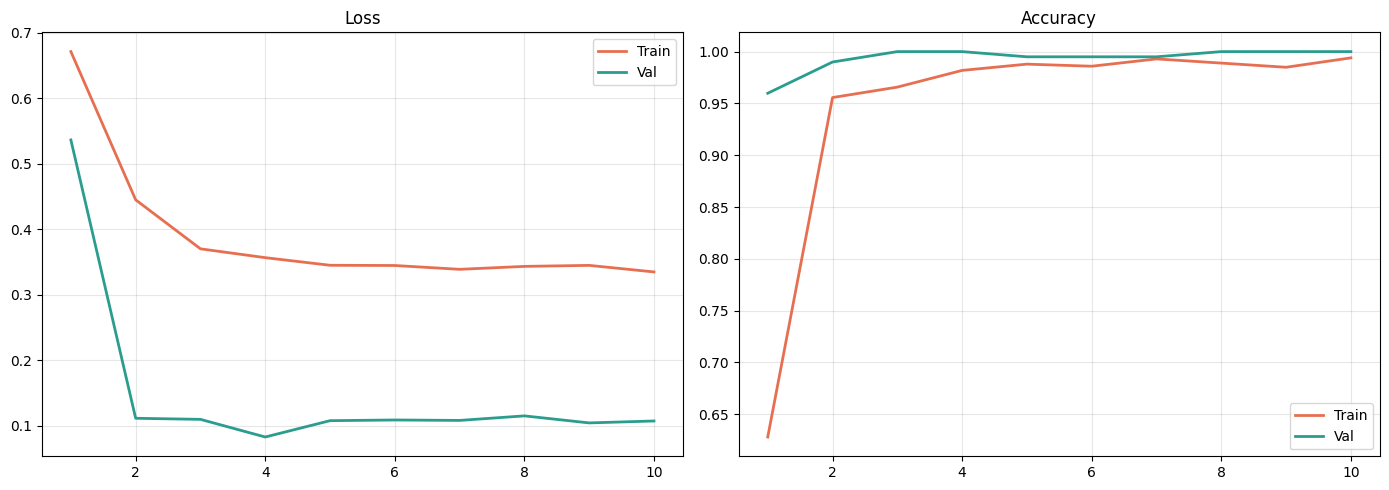

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
e = range(1, len(history["train_loss"]) + 1)

axes[0].plot(e, history["train_loss"], label="Train", color="#E76F51", lw=2)
axes[0].plot(e, history["val_loss"],   label="Val",   color="#2A9D8F", lw=2)
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e, history["train_acc"],  label="Train", color="#E76F51", lw=2)
axes[1].plot(e, history["val_acc"],    label="Val",   color="#2A9D8F", lw=2)
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/training_curves.png", dpi=150)
plt.show()

eval :   0%|          | 0/7 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000       102
       ulcer     1.0000    1.0000    1.0000        97

    accuracy                         1.0000       199
   macro avg     1.0000    1.0000    1.0000       199
weighted avg     1.0000    1.0000    1.0000       199



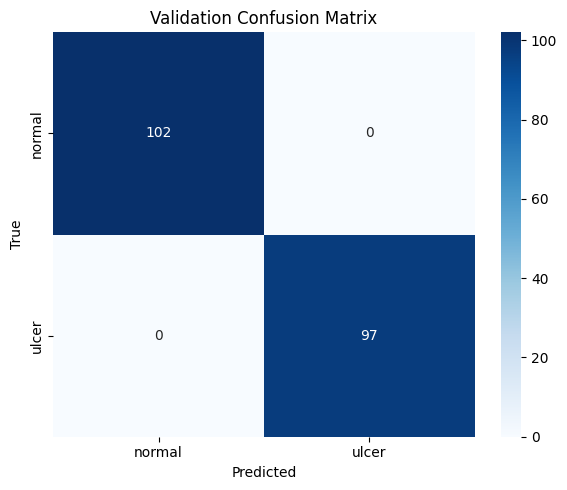

In [10]:
_, _, vl_preds, vl_labels, vl_probs = evaluate(model, val_ld)
print(classification_report(vl_labels, vl_preds, target_names=CLASSES, digits=4))

cm_val = confusion_matrix(vl_labels, vl_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Validation Confusion Matrix")
ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/val_confusion_matrix.png", dpi=150)
plt.show()

In [11]:
@torch.no_grad()
def tta_predict(model, dataset_root, class_names, tta_transforms):
    model.eval()
    all_probs, all_labels = [], []
    datasets = [DFUDataset(dataset_root, class_names, t) for t in tta_transforms]
    loaders  = [DataLoader(d, batch_size=CFG["batch_size"],
                           num_workers=CFG["num_workers"], pin_memory=True) for d in datasets]
    for ld in loaders:
        probs_this, labels_this = [], []
        for imgs, labels in tqdm(ld, leave=False, desc="TTA"):
            logits = model(imgs.to(DEVICE))
            probs_this .extend(F.softmax(logits, dim=1)[:, 1].cpu().numpy())
            labels_this.extend(labels.numpy())
        all_probs.append(probs_this)
        all_labels = labels_this
    avg_probs   = np.mean(all_probs, axis=0)
    final_preds = (avg_probs >= 0.5).astype(int)
    return final_preds, np.array(all_labels), avg_probs


te_preds, te_labels, te_probs = tta_predict(model, test_root, CLASSES, tta_tfs)
print(classification_report(te_labels, te_preds, target_names=CLASSES, digits=4))

  Loaded 208 images from ./dataset/test
  Loaded 208 images from ./dataset/test
  Loaded 208 images from ./dataset/test
  Loaded 208 images from ./dataset/test
  Loaded 208 images from ./dataset/test


TTA:   0%|          | 0/7 [00:00<?, ?it/s]

TTA:   0%|          | 0/7 [00:00<?, ?it/s]

TTA:   0%|          | 0/7 [00:00<?, ?it/s]

TTA:   0%|          | 0/7 [00:00<?, ?it/s]

TTA:   0%|          | 0/7 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000       108
       ulcer     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       208
   macro avg     1.0000    1.0000    1.0000       208
weighted avg     1.0000    1.0000    1.0000       208



ROC-AUC : 1.0000
PR-AUC  : 1.0000


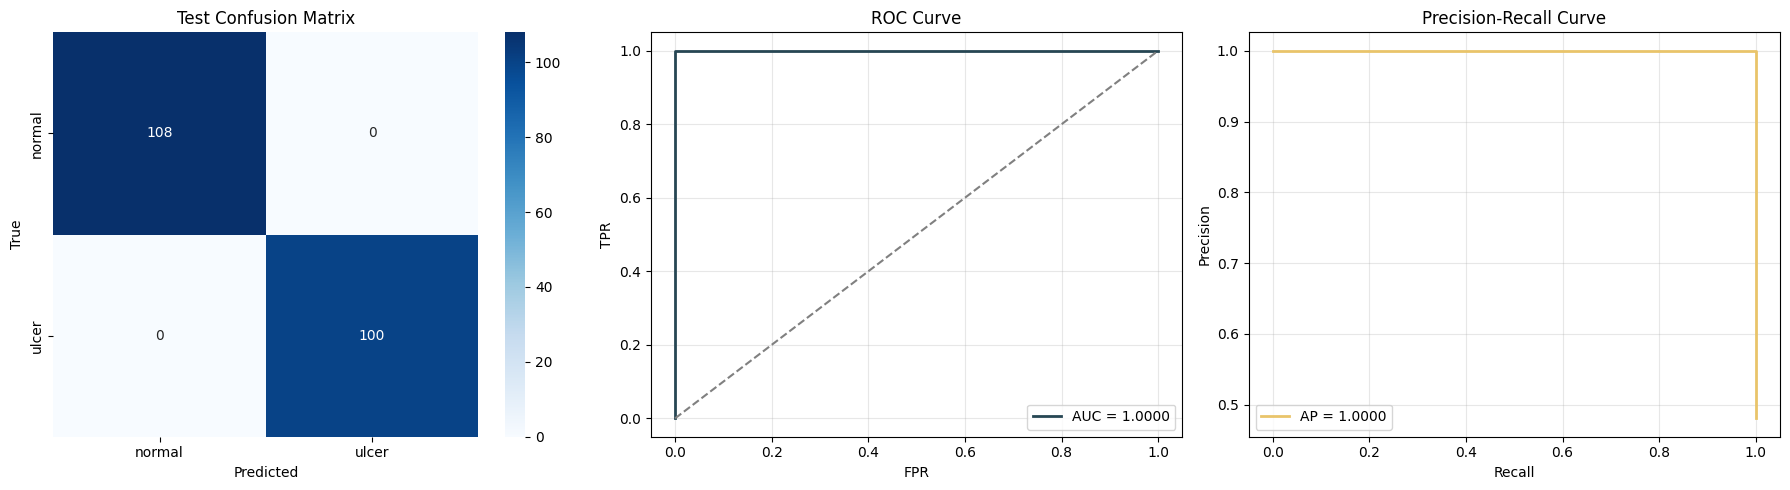

In [12]:
roc_auc = roc_auc_score(te_labels, te_probs)
pr_auc  = average_precision_score(te_labels, te_probs)
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_test = confusion_matrix(te_labels, te_preds)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Test Confusion Matrix")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

fpr, tpr, _ = roc_curve(te_labels, te_probs)
axes[1].plot(fpr, tpr, color="#264653", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0,1],[0,1],"--", color="gray")
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(); axes[1].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(te_labels, te_probs)
axes[2].plot(rec, prec, color="#E9C46A", lw=2, label=f"AP = {pr_auc:.4f}")
axes[2].set_title("Precision-Recall Curve"); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/test_evaluation_plots.png", dpi=150)
plt.show()

In [13]:
results = {
    "val_classification_report":  classification_report(vl_labels, vl_preds, target_names=CLASSES, digits=4, output_dict=True),
    "test_classification_report": classification_report(te_labels, te_preds, target_names=CLASSES, digits=4, output_dict=True),
    "test_roc_auc": round(roc_auc, 6),
    "test_pr_auc":  round(pr_auc,  6),
    "test_confusion_matrix": cm_test.tolist(),
}
with open(f"{CFG['save_dir']}/results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Saved results.json & best_model.pth\n")
print("="*55)
rep = results["test_classification_report"]
for cls in CLASSES:
    r = rep[cls]
    print(f"  {cls:<15} | P: {r['precision']:.4f}  R: {r['recall']:.4f}  "
          f"F1: {r['f1-score']:.4f}  Support: {int(r['support'])}")
print(f"\n  Macro F1  : {rep['macro avg']['f1-score']:.4f}")
print(f"  Accuracy  : {rep['accuracy']:.4f}")
print(f"  ROC-AUC   : {results['test_roc_auc']:.4f}")
print(f"  PR-AUC    : {results['test_pr_auc']:.4f}")

✅ Saved results.json & best_model.pth

  normal          | P: 1.0000  R: 1.0000  F1: 1.0000  Support: 108
  ulcer           | P: 1.0000  R: 1.0000  F1: 1.0000  Support: 100

  Macro F1  : 1.0000
  Accuracy  : 1.0000
  ROC-AUC   : 1.0000
  PR-AUC    : 1.0000


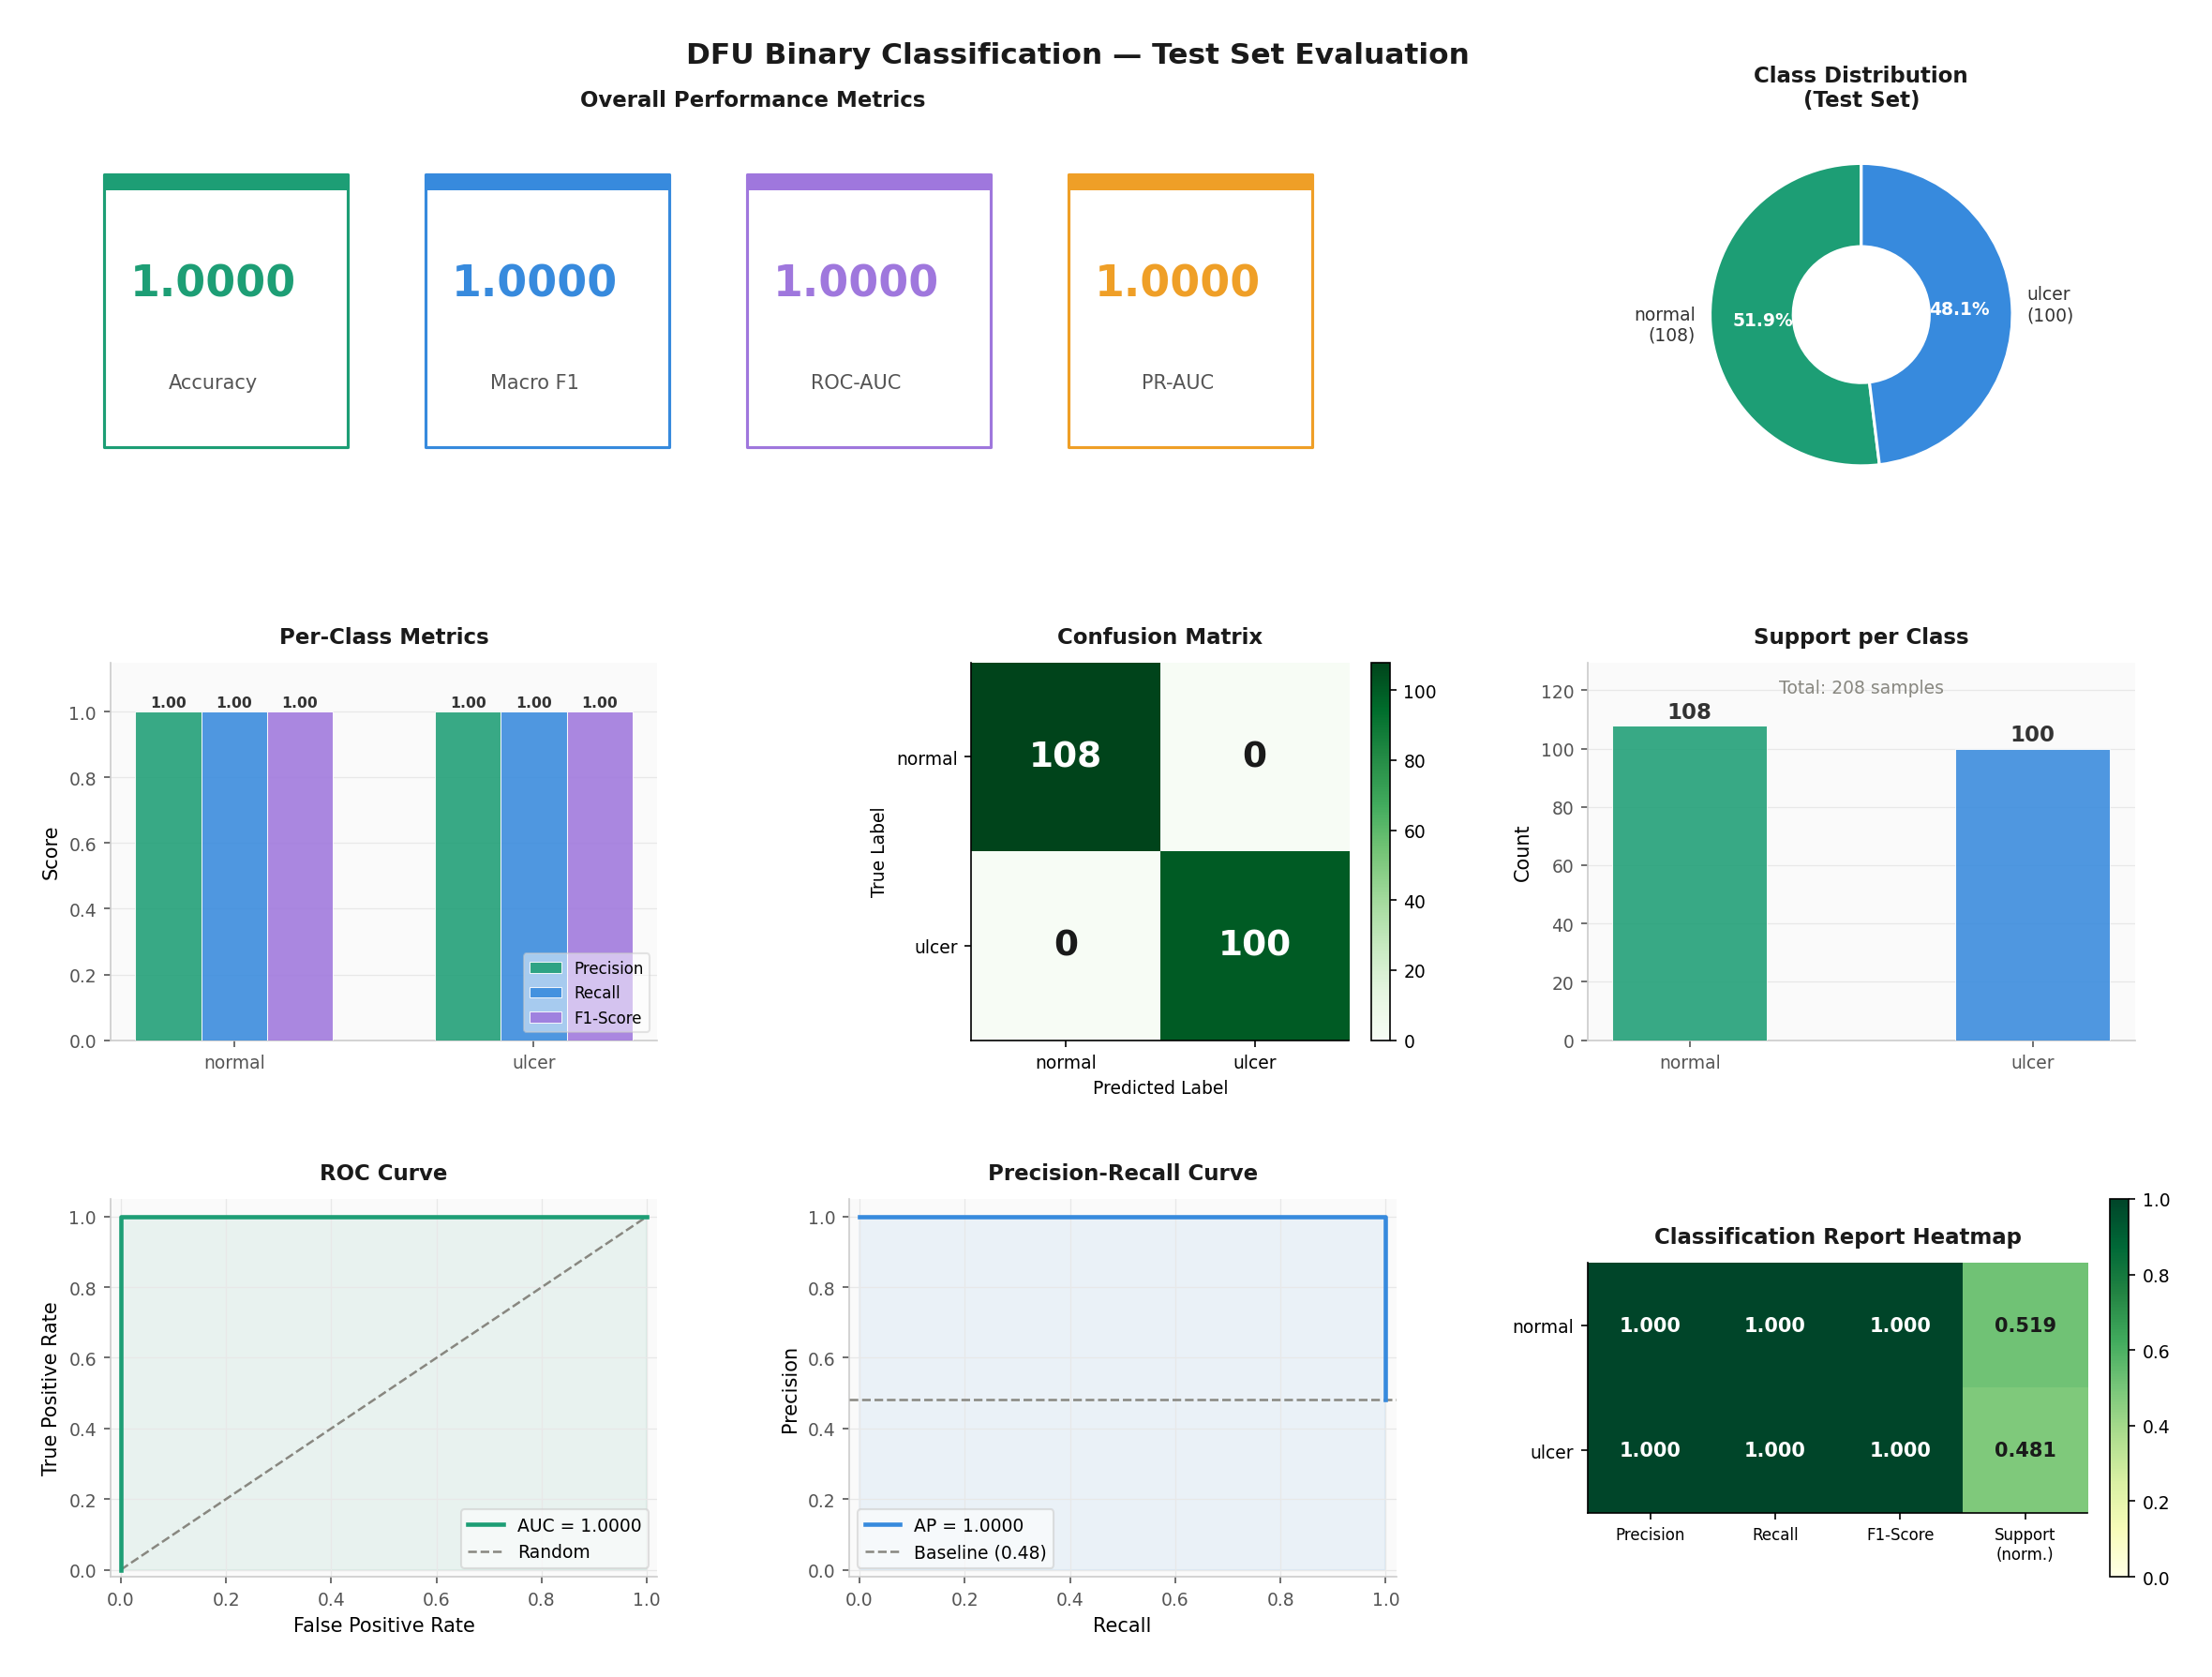

✅ Saved → ./outputs/evaluation_visualization.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve
import warnings
warnings.filterwarnings("ignore")

# ── Style config ──────────────────────────────────────────
plt.rcParams.update({
    "font.family"        : "DejaVu Sans",
    "font.size"          : 10,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.linewidth"     : 0.8,
    "axes.titlepad"      : 10,
    "axes.titlesize"     : 11,
    "axes.titleweight"   : "bold",
    "axes.labelsize"     : 10,
    "xtick.labelsize"    : 9,
    "ytick.labelsize"    : 9,
    "figure.dpi"         : 150,
    "savefig.dpi"        : 300,
    "savefig.bbox"       : "tight",
    "savefig.pad_inches" : 0.3,
})

TEAL      = "#1D9E75"
BLUE      = "#378ADD"
GRAY      = "#888780"
LIGHTGRAY = "#E8E8E8"
RED       = "#E24B4A"
BG        = "#FAFAFA"

# ── Pull data from existing variables ────────────────────
rep          = results["test_classification_report"]
cm           = np.array(results["test_confusion_matrix"])
roc_auc_val  = results["test_roc_auc"]
pr_auc_val   = results["test_pr_auc"]
accuracy     = rep["accuracy"]
macro_f1     = rep["macro avg"]["f1-score"]

cls_names    = CLASSES   # ["non_ulcer", "ulcer"]
precision_   = [rep[c]["precision"] for c in cls_names]
recall_      = [rep[c]["recall"]    for c in cls_names]
f1_          = [rep[c]["f1-score"]  for c in cls_names]
support_     = [int(rep[c]["support"]) for c in cls_names]

# ROC & PR curves from raw predictions (already computed above)
fpr, tpr, _ = roc_curve(te_labels, te_probs)
prec_curve, rec_curve, _ = precision_recall_curve(te_labels, te_probs)

# ── Figure layout ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor="white")
fig.suptitle(
    "DFU Binary Classification — Test Set Evaluation",
    fontsize=15, fontweight="bold", y=0.98, color="#1a1a1a"
)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.42,
    wspace=0.35,
    top=0.93, bottom=0.07,
    left=0.07, right=0.97
)

# ── Helper: styled axes ───────────────────────────────────
def style_ax(ax, title):
    ax.set_title(title, fontsize=11, fontweight="bold", color="#1a1a1a", pad=10)
    ax.set_facecolor(BG)
    ax.grid(axis="y", color=LIGHTGRAY, linewidth=0.6, zorder=0)
    ax.tick_params(colors="#555555")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")

# ═══════════════════════════════════════════════════════════
# Plot 1 — Overall metrics summary (top row, spans 2 cols)
# ═══════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(BG)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis("off")
ax1.set_title("Overall Performance Metrics", fontsize=11,
              fontweight="bold", color="#1a1a1a", pad=10)

metrics = {
    "Accuracy" : accuracy,
    "Macro F1" : macro_f1,
    "ROC-AUC"  : roc_auc_val,
    "PR-AUC"   : pr_auc_val,
}
colors_m = [TEAL, BLUE, "#9F77DD", "#EF9F27"]
positions = [0.08, 0.33, 0.58, 0.83]

for (name, val), col, xpos in zip(metrics.items(), colors_m, positions):
    # Card background
    rect = plt.Rectangle((xpos - 0.085, 0.15), 0.19, 0.72,
                          facecolor="white", edgecolor=col,
                          linewidth=1.5, transform=ax1.transAxes,
                          zorder=2, clip_on=False,
                          joinstyle="round")
    ax1.add_patch(rect)
    # Top color bar
    bar = plt.Rectangle((xpos - 0.085, 0.83), 0.19, 0.04,
                         facecolor=col, transform=ax1.transAxes,
                         zorder=3, clip_on=False)
    ax1.add_patch(bar)
    # Value
    ax1.text(xpos, 0.58, f"{val:.4f}",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color=col, transform=ax1.transAxes, zorder=4)
    # Label
    ax1.text(xpos, 0.32, name,
             ha="center", va="center",
             fontsize=10, color="#555555",
             transform=ax1.transAxes, zorder=4)

# ═══════════════════════════════════════════════════════════
# Plot 2 — Support pie chart (top row, col 3)
# ═══════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(BG)
wedge_colors = [TEAL, BLUE]
wedges, texts, autotexts = ax2.pie(
    support_,
    labels=[f"{c}\n({s})" for c, s in zip(cls_names, support_)],
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.65,
    wedgeprops=dict(linewidth=1.5, edgecolor="white", width=0.55)
)
for t in texts:
    t.set_fontsize(9)
    t.set_color("#333333")
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
ax2.set_title("Class Distribution\n(Test Set)", fontsize=11,
              fontweight="bold", color="#1a1a1a", pad=10)

# ═══════════════════════════════════════════════════════════
# Plot 3 — Per-class Precision, Recall, F1 grouped bar
# ═══════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, "Per-Class Metrics")

x      = np.arange(len(cls_names))
width  = 0.22
bars_p = ax3.bar(x - width,     precision_, width, label="Precision",
                 color=TEAL,  alpha=0.88, zorder=3, edgecolor="white", linewidth=0.5)
bars_r = ax3.bar(x,            recall_,    width, label="Recall",
                 color=BLUE,  alpha=0.88, zorder=3, edgecolor="white", linewidth=0.5)
bars_f = ax3.bar(x + width,    f1_,        width, label="F1-Score",
                 color="#9F77DD", alpha=0.88, zorder=3, edgecolor="white", linewidth=0.5)

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.2f}", ha="center", va="bottom",
                 fontsize=7.5, color="#333333", fontweight="bold")

ax3.set_xticks(x)
ax3.set_xticklabels([c.replace("_", "\n") for c in cls_names], fontsize=9)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score")
ax3.legend(fontsize=8, framealpha=0.5, loc="lower right")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}"))

# ═══════════════════════════════════════════════════════════
# Plot 4 — Confusion Matrix heatmap
# ═══════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(BG)
ax4.set_title("Confusion Matrix", fontsize=11,
              fontweight="bold", color="#1a1a1a", pad=10)

cmap   = plt.cm.get_cmap("Greens")
im     = ax4.imshow(cm, interpolation="nearest", cmap=cmap, vmin=0)
thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax4.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 fontsize=18, fontweight="bold",
                 color="white" if cm[i, j] > thresh else "#1a1a1a")

tick_marks = np.arange(len(cls_names))
ax4.set_xticks(tick_marks)
ax4.set_yticks(tick_marks)
ax4.set_xticklabels([c.replace("_", "\n") for c in cls_names], fontsize=9)
ax4.set_yticklabels([c.replace("_", "\n") for c in cls_names], fontsize=9)
ax4.set_xlabel("Predicted Label", fontsize=9)
ax4.set_ylabel("True Label", fontsize=9)
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

# ═══════════════════════════════════════════════════════════
# Plot 5 — Per-class Support bar
# ═══════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5, "Support per Class")

bars = ax5.bar(
    [c.replace("_", "\n") for c in cls_names],
    support_,
    color=[TEAL, BLUE],
    alpha=0.88, zorder=3,
    edgecolor="white", linewidth=0.5,
    width=0.45
)
for bar, val in zip(bars, support_):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha="center", va="bottom",
             fontsize=11, fontweight="bold", color="#333333")

total = sum(support_)
ax5.text(0.5, 0.92, f"Total: {total} samples",
         ha="center", transform=ax5.transAxes,
         fontsize=9, color=GRAY)
ax5.set_ylabel("Count")
ax5.set_ylim(0, max(support_) * 1.2)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))

# ═══════════════════════════════════════════════════════════
# Plot 6 — ROC Curve
# ═══════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[2, 0])
style_ax(ax6, "ROC Curve")
ax6.grid(axis="both", color=LIGHTGRAY, linewidth=0.6, zorder=0)

ax6.plot(fpr, tpr, color=TEAL, lw=2.2, zorder=4,
         label=f"AUC = {roc_auc_val:.4f}")
ax6.fill_between(fpr, tpr, alpha=0.08, color=TEAL)
ax6.plot([0, 1], [0, 1], color=GRAY, lw=1.2,
         linestyle="--", zorder=3, label="Random")
ax6.set_xlim([-0.02, 1.02])
ax6.set_ylim([-0.02, 1.05])
ax6.set_xlabel("False Positive Rate")
ax6.set_ylabel("True Positive Rate")
ax6.legend(fontsize=9, framealpha=0.6, loc="lower right")

# ═══════════════════════════════════════════════════════════
# Plot 7 — Precision-Recall Curve
# ═══════════════════════════════════════════════════════════
ax7 = fig.add_subplot(gs[2, 1])
style_ax(ax7, "Precision-Recall Curve")
ax7.grid(axis="both", color=LIGHTGRAY, linewidth=0.6, zorder=0)

baseline = support_[1] / sum(support_)
ax7.plot(rec_curve, prec_curve, color=BLUE, lw=2.2, zorder=4,
         label=f"AP = {pr_auc_val:.4f}")
ax7.fill_between(rec_curve, prec_curve, alpha=0.08, color=BLUE)
ax7.axhline(y=baseline, color=GRAY, lw=1.2,
            linestyle="--", zorder=3,
            label=f"Baseline ({baseline:.2f})")
ax7.set_xlim([-0.02, 1.02])
ax7.set_ylim([-0.02, 1.05])
ax7.set_xlabel("Recall")
ax7.set_ylabel("Precision")
ax7.legend(fontsize=9, framealpha=0.6, loc="lower left")

# ═══════════════════════════════════════════════════════════
# Plot 8 — Full classification report heatmap
# ═══════════════════════════════════════════════════════════
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor(BG)
ax8.set_title("Classification Report Heatmap", fontsize=11,
              fontweight="bold", color="#1a1a1a", pad=10)

report_data = np.array([
    [rep[c]["precision"], rep[c]["recall"],
     rep[c]["f1-score"],  rep[c]["support"] / sum(support_)]
    for c in cls_names
])
col_labels  = ["Precision", "Recall", "F1-Score", "Support\n(norm.)"]
row_labels  = [c.replace("_", "\n") for c in cls_names]

im2 = ax8.imshow(report_data, interpolation="nearest",
                 cmap=plt.cm.get_cmap("YlGn"), vmin=0, vmax=1)

for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = report_data[i, j]
        ax8.text(j, i, f"{val:.3f}",
                 ha="center", va="center",
                 fontsize=10, fontweight="bold",
                 color="white" if val > 0.6 else "#1a1a1a")

ax8.set_xticks(range(len(col_labels)))
ax8.set_yticks(range(len(row_labels)))
ax8.set_xticklabels(col_labels, fontsize=8)
ax8.set_yticklabels(row_labels, fontsize=9)
plt.colorbar(im2, ax=ax8, fraction=0.046, pad=0.04)

# ── Save & show ───────────────────────────────────────────
plt.savefig(f"{CFG['save_dir']}/evaluation_visualization.png",
            dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"✅ Saved → {CFG['save_dir']}/evaluation_visualization.png")